In [14]:
!pip install yfinance

In [15]:
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt


In [16]:
assets = ['AAPL', 'KO', 'GLD']

# Tải dữ liệu từ YahooF
raw_data = yf.download(assets, start="2021-01-01", end="2026-01-01")

# Lấy cột giá Close
data = raw_data['Close']

# Tính tỷ suất sinh lợi hàng ngày
log_returns = np.log(data / data.shift(1)).dropna()

# Khai báo các biến mô phỏng Monte Cario
num_portfolios = 5000
results = np.zeros((3, num_portfolios))
weights_record = []

# Chạy ngẫu nhiên danh mục
for i in range(num_portfolios):
    # Tạo weight ngẫu nhiên sao cho 3 tài sản tổng bằng 1.0
    weights = np.random.random(len(assets))
    weights /= np.sum(weights)
    weights_record.append(weights)

portfolio_return = np.sum(log_returns.mean() * weights) * 252
portfolio_std_dev = np.sqrt(np.dot(weights.T, np.dot(log_returns.cov() * 252, weights)))

results[0, i] = portfolio_return
results[1, i] = portfolio_std_dev
results[2, i] = portfolio_return / portfolio_std_dev


[*********************100%***********************]  3 of 3 completed


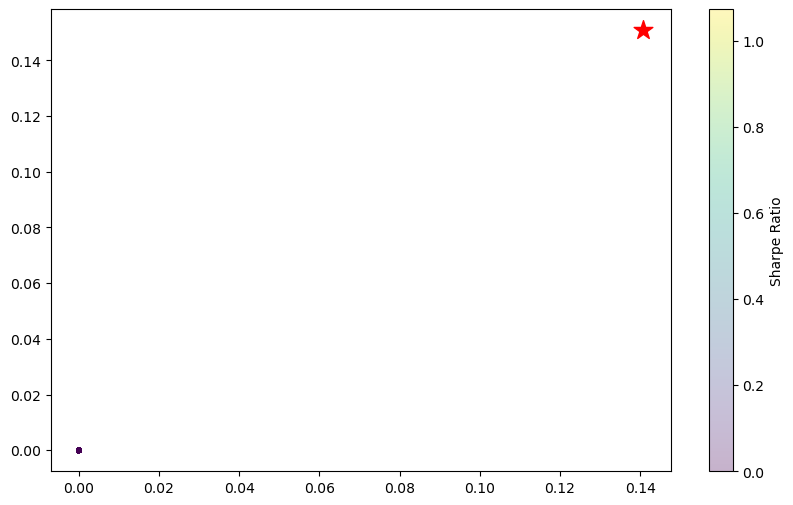

In [17]:
# Tìm và đánh dấu danh mục có Sharpe Ratio lớn nhất
max_sharpe_idx = np.argmax(results[2])
sdp, rp = results[1, max_sharpe_idx], results[0, max_sharpe_idx]
best_weights = weights_record[max_sharpe_idx]

# Vẽ biểu đồ nhaaa, Efficient Frontier
plt.figure(figsize=(10, 6))
scatter = plt.scatter(results[1,:], results[0,:], c=results[2,:], cmap='viridis', marker='o', s=10, alpha=0.3)
plt.colorbar(scatter, label='Sharpe Ratio')

plt.scatter(sdp, rp, marker='*', color='red', s=200, label='Maximum Sharpe Ratio (Best)')
...
plt.show()

In [18]:
print("---DANH MỤC TỐI ƯU NHẤT---")
for asset, weight in zip(assets, best_weights):
    print(f"{asset}: {weight*100:.2f}%")

---DANH MỤC TỐI ƯU NHẤT---
AAPL: 34.82%
KO: 58.37%
GLD: 6.81%
